In [13]:
import torch

# Clean up memory from previous runs
if 'model' in locals():
    del model
if 'input_tensor' in locals():
    del input_tensor
if 'output_tensor' in locals():
    del output_tensor
if 'state_dict' in locals():
    del state_dict

torch.cuda.empty_cache()
print("GPU memory cleared.")

GPU memory cleared.


# Dequantization Model Inference
This notebook demonstrates how to load a trained `Dequantization-Net` model and run inference on a test image.

In [14]:
import os
import sys
from pathlib import Path

import torch
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# Add project root to sys.path to allow imports from luminascale
project_root = Path("/mnt/MKP01/med8_project/LuminaScale")
if str(project_root / "src") not in sys.path:
    sys.path.insert(0, str(project_root / "src"))

from luminascale.models import create_dequantization_net


In [15]:
# Configuration for inference
model_path = project_root / "dataset/temp/test_run/dequant_net_epoch_1.pt"
image_path = project_root / "dataset/temp/srgb_looks/10_1.png"
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")  # Force CPU for testing
print(f"Using device: {device}")
print(f"Loading model from: {model_path}")
print(f"Processing image: {image_path}")

# 1. Create the model instance
# Note: Use the same base_channels as when training (The test config used 32)
model = create_dequantization_net(device=device, base_channels=32)

# 2. Load the state dict
state_dict = torch.load(model_path, map_location=device)
model.load_state_dict(state_dict)
model.eval()

# DELETE state_dict after loading to free memory
del state_dict
torch.cuda.empty_cache()

print("Model successfully loaded and set to evaluation mode.")

Using device: cpu
Loading model from: /mnt/MKP01/med8_project/LuminaScale/dataset/temp/test_run/dequant_net_epoch_1.pt
Processing image: /mnt/MKP01/med8_project/LuminaScale/dataset/temp/srgb_looks/10_1.png
Model successfully loaded and set to evaluation mode.


In [16]:
# 3. Preprocess the input image
# Input is an sRGB PNG. The dataset expects [0, 1] range float32.
input_img = Image.open(image_path).convert("RGB")
input_np = np.array(input_img).transpose(2, 0, 1).astype(np.float32) / 255.0

# Ensure dimensions are divisible by 32 for the U-Net architecture (5 levels of padding/pooling)
h, w = input_np.shape[1], input_np.shape[2]
new_h = (h // 32) * 32
new_w = (w // 32) * 32

if h != new_h or w != new_w:
    print(f"Resizing input from {h}x{w} to {new_h}x{new_w} to satisfy U-Net alignment...")
    input_tensor = torch.from_numpy(input_np).unsqueeze(0)
    input_tensor = F.interpolate(input_tensor, size=(new_h, new_w), mode='bilinear', align_corners=False)
else:
    input_tensor = torch.from_numpy(input_np).unsqueeze(0)

input_tensor = input_tensor.to(device)
print(f"Final Input shape: {input_tensor.shape}")

# 4. Perform Inference
with torch.no_grad():
    output_tensor = model(input_tensor)

print(f"Output shape: {output_tensor.shape}")

Resizing input from 3464x5202 to 3456x5184 to satisfy U-Net alignment...
Final Input shape: torch.Size([1, 3, 3456, 5184])
Output shape: torch.Size([1, 3, 3456, 5184])


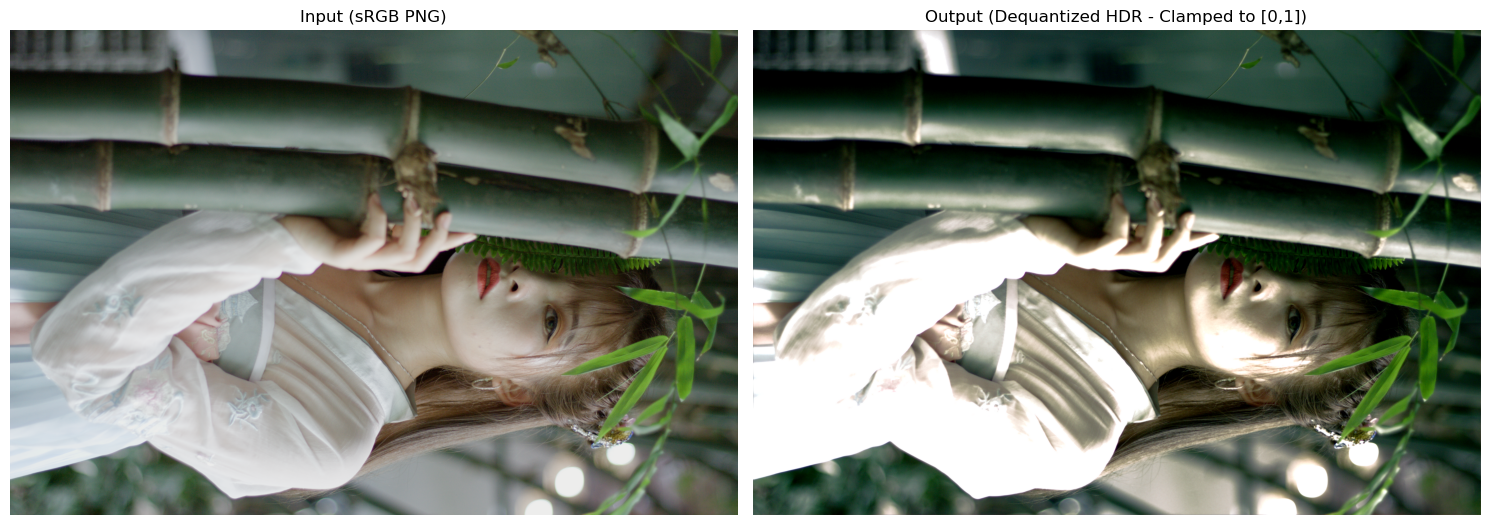

Max intensity in HDR output: 1.9384222030639648
Mean intensity: 0.5151786804199219


In [17]:
# 5. Visualize Results
# Convert back to numpy for matplotlib
# The output tensor is HDR, so we might need some tone-mapping or clamping for basic viewing
input_display = input_tensor.squeeze(0).cpu().permute(1, 2, 0).numpy()
output_display = output_tensor.squeeze(0).detach().cpu().permute(1, 2, 0).numpy()

# Simple tone-mapping for HDR visualization (log or clamping)
# ACES-like visualization: 
output_tonemapped = np.clip(output_display, 0, 1)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
axes[0].imshow(input_display)
axes[0].set_title("Input (sRGB PNG)")
axes[0].axis("off")

axes[1].imshow(output_tonemapped)
axes[1].set_title("Output (Dequantized HDR - Clamped to [0,1])")
axes[1].axis("off")

plt.tight_layout()
plt.show()

print(f"Max intensity in HDR output: {output_display.max()}")
print(f"Mean intensity: {output_display.mean()}")
